In [1]:
import pandas as pd

df = pd.read_csv(r"D:\sem 4\MAcro project\final_preprocessed_ipl.csv")

print(df.head())
print(df.columns)

       id        city        date player_of_match  \
0  335982   Bangalore  2008-04-18     BB McCullum   
1  335983  Chandigarh  2008-04-19      MEK Hussey   
2  335984       Delhi  2008-04-19     MF Maharoof   
3  335985      Mumbai  2008-04-20      MV Boucher   
4  335986     Kolkata  2008-04-20       DJ Hussey   

                                        venue neutral_venue  \
0                       M Chinnaswamy Stadium            No   
1  Punjab Cricket Association Stadium, Mohali            No   
2                            Feroz Shah Kotla            No   
3                            Wankhede Stadium            No   
4                                Eden Gardens            No   

                         team1                        team2  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1              Kings XI Punjab          Chennai Super Kings   
2             Delhi Daredevils             Rajasthan Royals   
3               Mumbai Indians  Royal Challengers 

In [2]:
df['team1'] = df['team1'].str.strip()
df['team2'] = df['team2'].str.strip()
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

In [3]:
team_to_code = {
"Chennai Super Kings":0,
"Deccan Chargers":1,
"Delhi Capitals":2,
"Delhi Daredevils":3,
"Gujarat Lions":4,
"Kings XI Punjab":5,
"Kochi Tuskers Kerala":6,
"Kolkata Knight Riders":7,
"Mumbai Indians":8,
"Pune Warriors":9,
"Rajasthan Royals":10,
"Rising Pune Supergiant":11,
"Rising Pune Supergiants":12,
"Royal Challengers Bangalore":13,
"Sunrisers Hyderabad":14
}

code_to_team = {v:k for k,v in team_to_code.items()}

valid_teams = list(team_to_code.keys())

In [4]:
features = [
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'venue',
    'match_type',
    'toss_impact',
    'margin_category'
]



In [5]:
df['winner'] = df['winner'].fillna("No Result")

In [6]:
df.replace({
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}, inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in features + ['winner']:
    
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
    encoders[col] = le

In [8]:
X = df[features]
y = df['winner']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
from sklearn.metrics import accuracy_score

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7195121951219512


In [12]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(y.unique()), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50


C:\Users\ARNAV MAHAJAN\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1825 - loss: 2.4817   
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2638 - loss: 2.2260 
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2638 - loss: 2.1808 
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2807 - loss: 2.1242 
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3006 - loss: 2.0750 
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3190 - loss: 2.0274 
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.3267 - loss: 2.0040
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.3083 - loss: 2.0033
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.3650 - loss: 1.9325
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3604 - loss: 1.9038 
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3666 - loss: 1.8778 
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - accuracy: 0.36

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("TensorFlow Model Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 1.0681 
TensorFlow Model Accuracy: 0.75


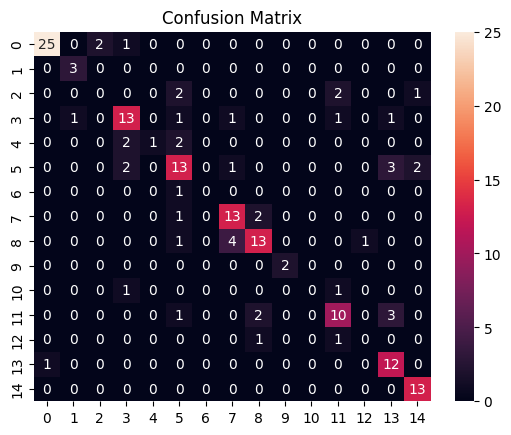

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = rf_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [15]:
importance = rf_model.feature_importances_

for i, v in enumerate(importance):
    print(features[i], ":", v)

team1 : 0.22193895367139996
team2 : 0.18631185573416303
toss_winner : 0.24916368802880506
toss_decision : 0.03298195871369442
venue : 0.17188553731706607
match_type : 0.008014872783361193
toss_impact : 0.10754362747292996
margin_category : 0.022159506278580238


In [16]:
teams = encoders['team1'].classes_

print("Available Teams:")
for t in teams:
    print(t)

Available Teams:
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Mumbai Indians
Pune Warriors
Rajasthan Royals
Rising Pune Supergiant
Royal Challengers Bangalore
Sunrisers Hyderabad


In [17]:
print("Teams:", encoders['team1'].classes_)
print("Toss Decisions:", encoders['toss_decision'].classes_)
print("Venues:", encoders['venue'].classes_)
print("Match Types:", encoders['match_type'].classes_)
print("Toss Impact:", encoders['toss_impact'].classes_)
print("Margin Category:", encoders['margin_category'].classes_)

Teams: ['Chennai Super Kings' 'Deccan Chargers' 'Delhi Capitals'
 'Delhi Daredevils' 'Gujarat Lions' 'Kings XI Punjab'
 'Kochi Tuskers Kerala' 'Kolkata Knight Riders' 'Mumbai Indians'
 'Pune Warriors' 'Rajasthan Royals' 'Rising Pune Supergiant'
 'Royal Challengers Bangalore' 'Sunrisers Hyderabad']
Toss Decisions: ['bat' 'field']
Venues: ['Barabati Stadium' 'Brabourne Stadium' 'Buffalo Park'
 'De Beers Diamond Oval' 'Dr DY Patil Sports Academy'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Dubai International Cricket Stadium' 'Eden Gardens' 'Feroz Shah Kotla'
 'Green Park' 'Himachal Pradesh Cricket Association Stadium'
 'Holkar Cricket Stadium' 'JSCA International Stadium Complex' 'Kingsmead'
 'M Chinnaswamy Stadium' 'M.Chinnaswamy Stadium'
 'MA Chidambaram Stadium, Chepauk'
 'Maharashtra Cricket Association Stadium' 'Nehru Stadium'
 'New Wanderers Stadium' 'Newlands' 'OUTsurance Oval'
 'Punjab Cricket Association IS Bindra Stadium, Mohali'
 'Punjab Cricket Association Stadiu

In [18]:
team_map = {
0: "Chennai Super Kings",
1: "Deccan Chargers",
2: "Delhi Capitals",
3: "Delhi Daredevils",
4: "Gujarat Lions",
5: "Kings XI Punjab",
6: "Kochi Tuskers Kerala",
7: "Kolkata Knight Riders",
8: "Mumbai Indians",
9: "Pune Warriors",
10: "Rajasthan Royals",
11: "Rising Pune Supergiant",
12: "Rising Pune Supergiants",
13: "Royal Challengers Bangalore",
14: "Sunrisers Hyderabad"
}

In [19]:
def predict_match_auto(team1, team2, match_date):

    if team1 not in valid_teams or team2 not in valid_teams:
        print("❌ You have given wrong data")
        return
    
    match = df[
        (
            ((df['team1'] == team_to_code[team1]) &
             (df['team2'] == team_to_code[team2]))
            |
            ((df['team1'] == team_to_code[team2]) &
             (df['team2'] == team_to_code[team1]))
        )
        &
        (df['date'] == match_date)
    ]

    if match.empty:
        print("❌ Match not found in dataset")
        return

    row = match.iloc[0]
    input_data = pd.DataFrame([[
        row['team1'],
        row['team2'],
        row['toss_winner'],
        0 if row['toss_decision'] == "bat" else 1,
        row['venue'],
        row['match_type'],
        row['toss_impact'],
        row['margin_category']
    ]], columns=features)

    prediction = rf_model.predict(input_data)[0]
    prob = rf_model.predict_proba(input_data)

    predicted_winner = code_to_team[prediction]
    actual_winner = code_to_team[row['winner']]

    confidence = max(prob[0]) * 100

    print("\n📅 Match Date:", match_date)
    print("🏏 Team 1:", team1)
    print("🏏 Team 2:", team2)

    print("\n✅ Actual Winner:", actual_winner)
    print("🤖 Predicted Winner:", predicted_winner)
    print("📊 Prediction Confidence:", round(confidence, 2), "%")

In [25]:
team1 = input("Enter Team 1: ")
team2 = input("Enter Team 2: ")
match_date = input("Enter Match Date (YYYY-MM-DD): ")

predict_match_auto(team1, team2, match_date)


📅 Match Date: 2011-05-18
🏏 Team 1: Chennai Super Kings
🏏 Team 2: Kochi Tuskers Kerala

✅ Actual Winner: Chennai Super Kings
🤖 Predicted Winner: Chennai Super Kings
📊 Prediction Confidence: 90.85 %
